## RFlag Model test

Test on first 3C129.

In [2]:
import sys
sys.path.append('../')
import numpy as np

In [3]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/one_antenna_3C129_rflag.ms'

datarfi_3C129 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C129.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


100%|██████████| 1/1 [00:20<00:00, 20.16s/it]


(26, 4, 2048, 511)


In [4]:
datarfi_3C129.load(ant_i=1, mode='FLAG')


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:07<00:00,  7.39s/it]


In [30]:
datarfi_3C129.flags = np.abs(datarfi_3C129.ms_flags)

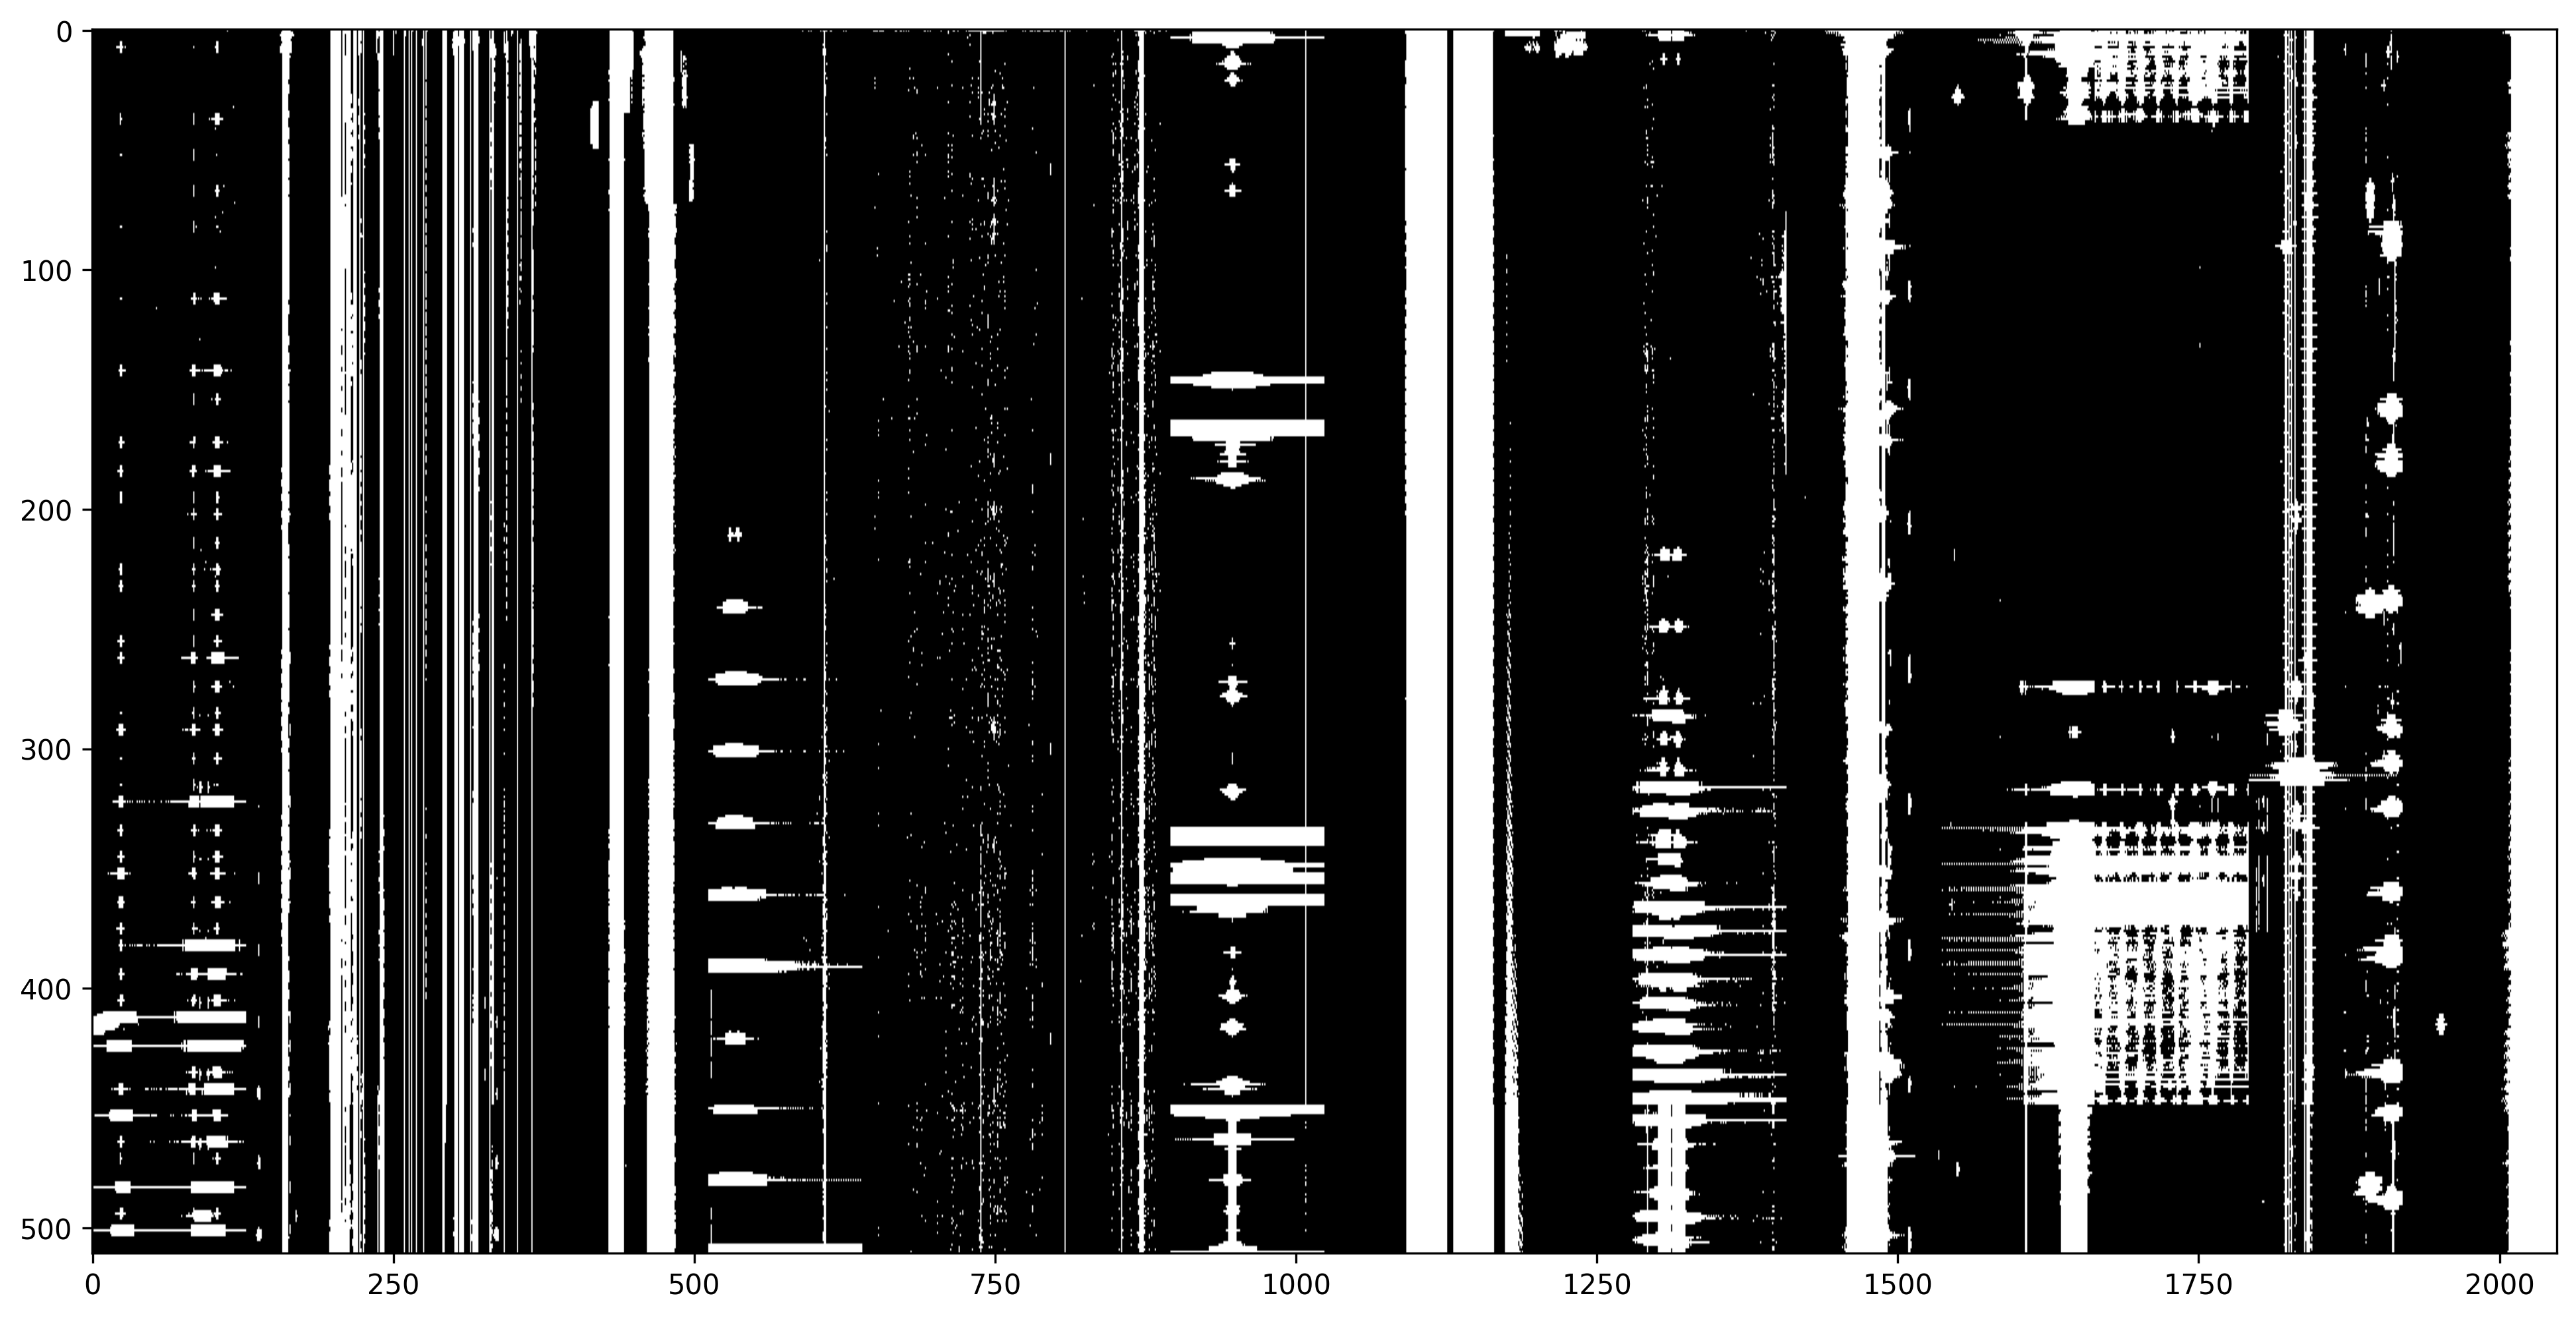

In [34]:
datarfi_3C129.plotter.plot(baseline=10, polarization=0, mode='FLAG')

In [33]:
datarfi_3C129.radio_metrics.test_realdata()

100%|██████████| 26/26 [08:39<00:00, 19.99s/it]


,Baseline,Polarization,RFI_Percent_Flagged,Calcquality_Score,Calcquality_Blank_Flag
0,0,0,20.314029,24.235522,250.289139
1,0,1,20.314029,29.171024,286.942819
2,0,2,20.314029,26.581580,258.544630
3,0,3,20.314029,31.226734,895.413733
4,1,0,10.947820,31.413861,315.267170
...,...,...,...,...,...
99,24,3,20.602029,31.999823,825.874024
100,25,0,15.274125,24.883016,333.983097
101,25,1,15.274125,28.244974,327.689330
102,25,2,15.274125,32.885767,471.941305


In [7]:
import time

In [8]:
from samrfi import RFIModels
sam_checkpoint = "/home/gpuhost002/ddeal/RFI-AI/models/sam_vit_h_4b8939.pth"
sam_type = "vit_h"

model_path = "/home/gpuhost002/ddeal/RFI-AI/samrfi_data/models/model_stretch-3C147_RFlag_patch-patchify_size-256_sam-huge_epochs60_20250103_030325.pth"
model = RFIModels(sam_checkpoint, sam_type, radiorfi_instance=datarfi_3C129, device='cuda',)
model.load_model(model_path)

start_time = time.time()

model.run_rfi_model(patch_run=True, threshold=0.5)

end_time = time.time()

duration = end_time - start_time

output_filename = f'/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/flagdata_duration_3C129_rflag_model.txt'
with open(output_filename, 'w') as f:
    f.write(f"Flagdata operation on one_antenna_3C129_rflag.ms with the rflag model took {duration:.2f} seconds. Patch run is true, sliding patch is false. Threshold is 0.5\n")

(26, 4, 2048, 511)
SAMRFI Progress...


100%|██████████| 26/26 [18:09<00:00, 41.91s/it]


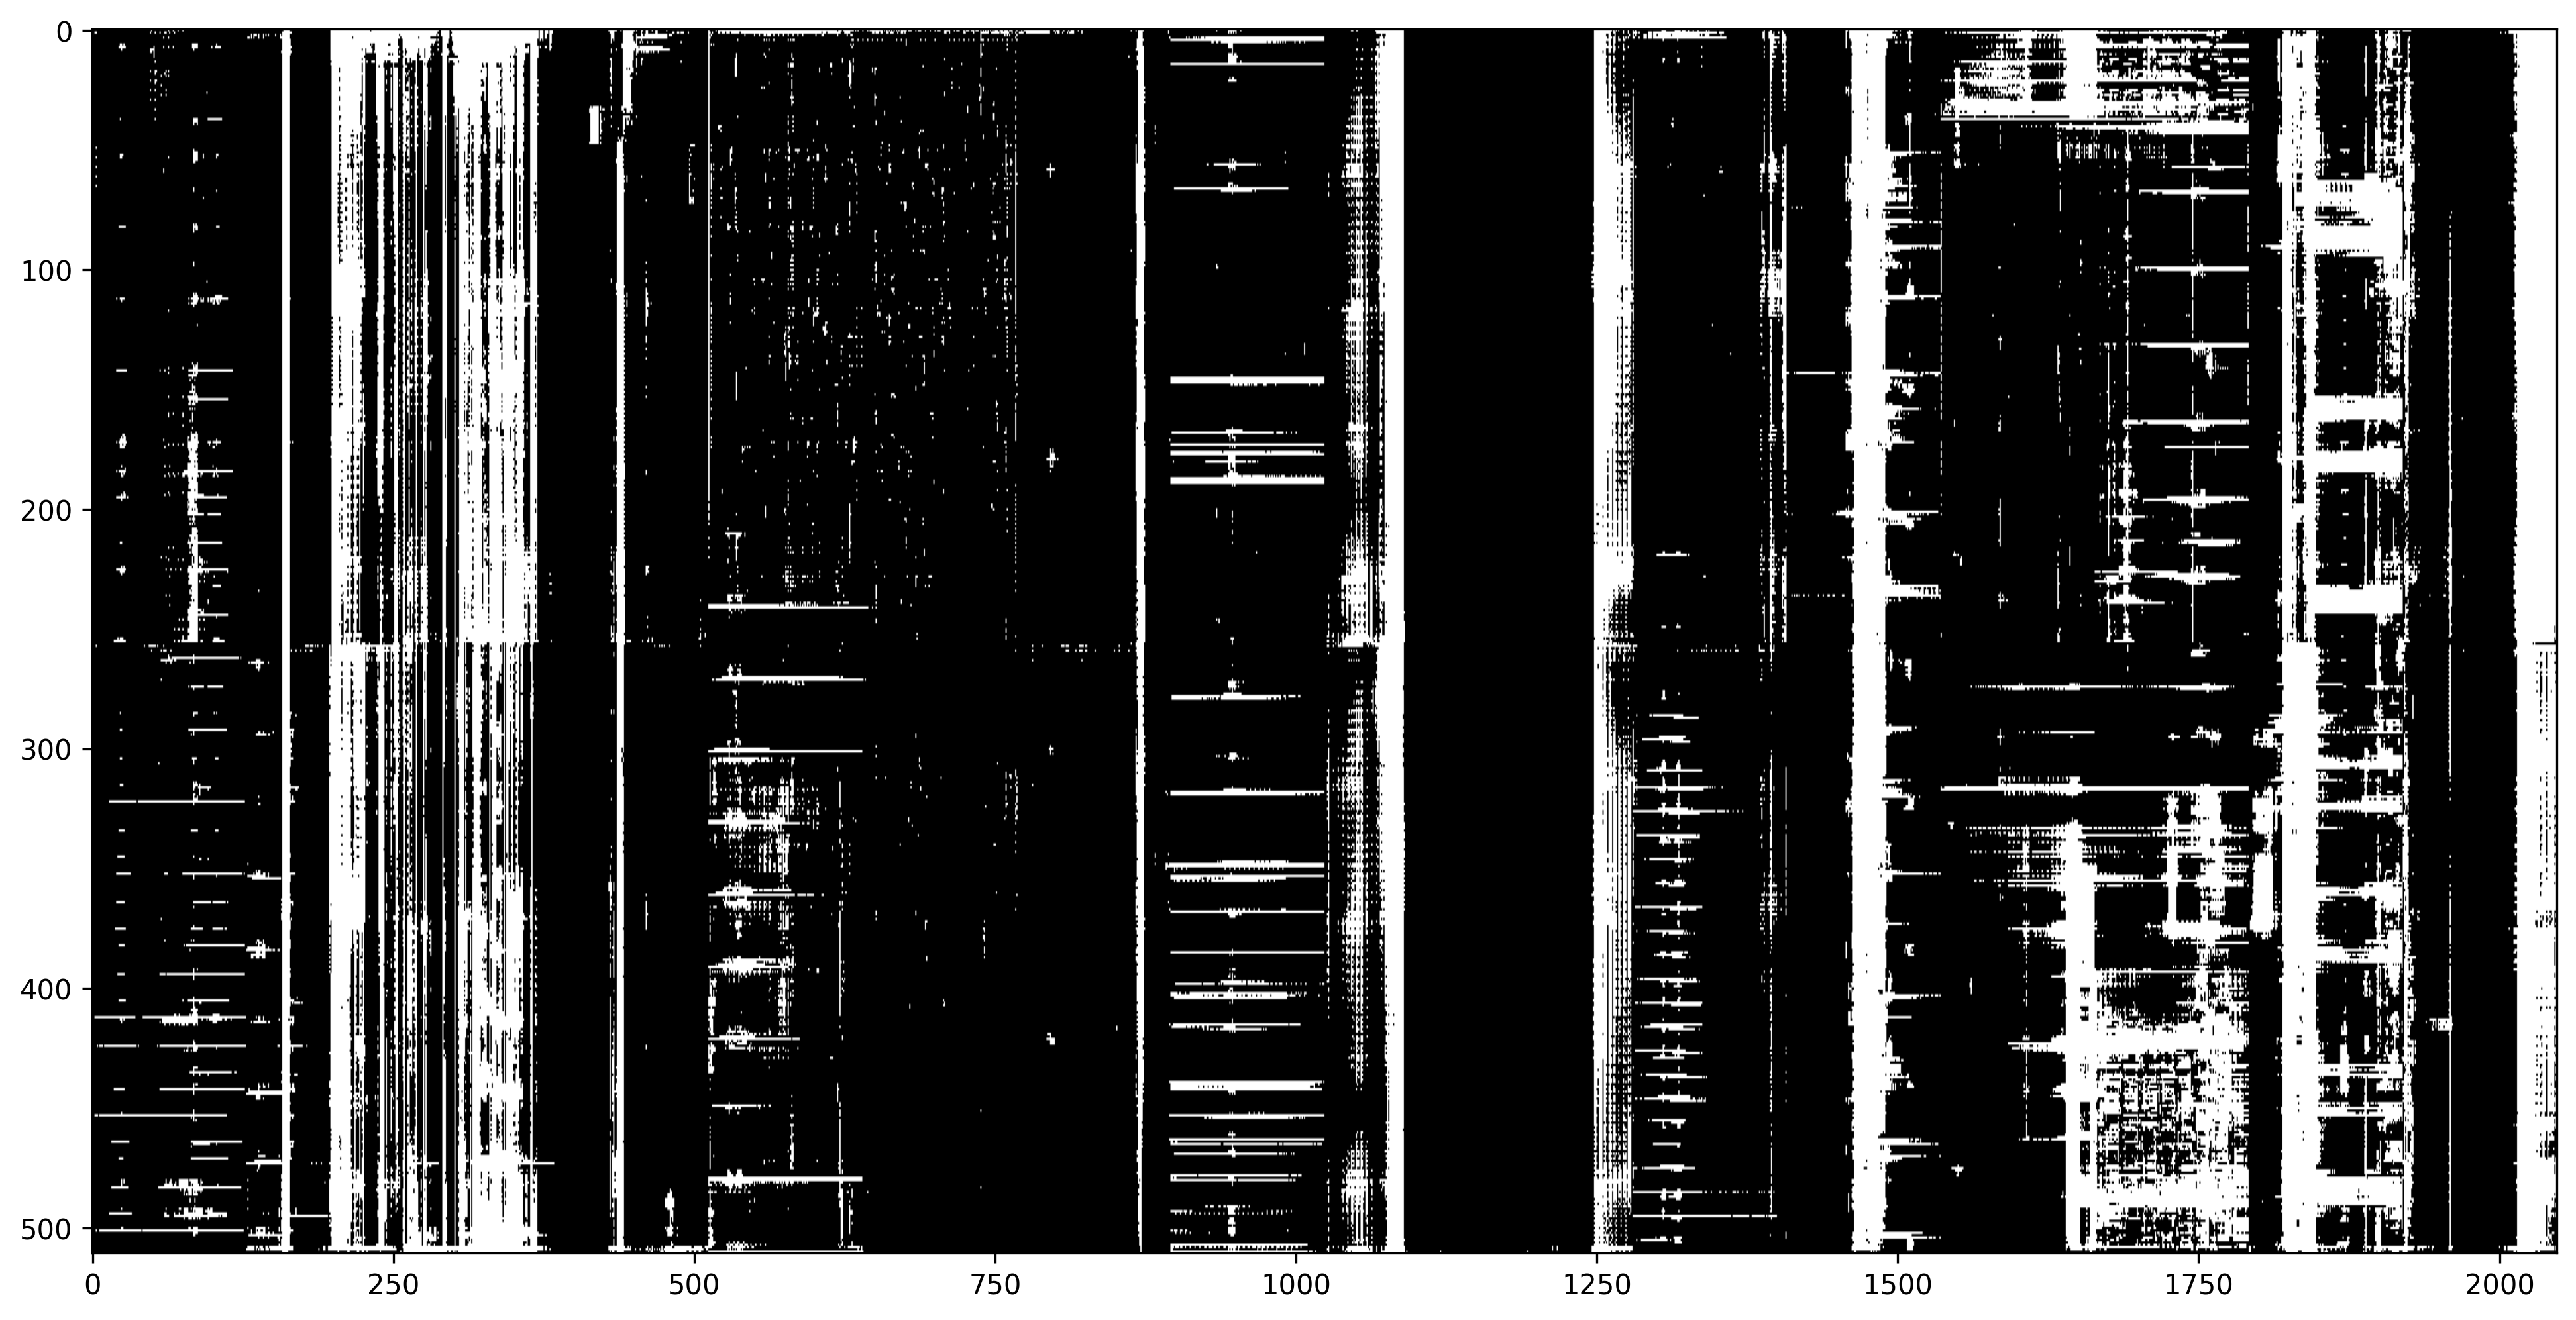

In [9]:
datarfi_3C129.plotter.plot(baseline=0, polarization=0, mode='FLAG')

In [10]:
datarfi_3C129.radio_metrics.test_realdata()

100%|██████████| 26/26 [08:40<00:00, 20.02s/it]


,Baseline,Polarization,RFI_Percent_Flagged,Calcquality_Score,Calcquality_Blank_Flag
0,0,0,18.659415,158.402700,250.289139
1,0,1,17.460498,272.766719,286.942819
2,0,2,16.812355,128.259550,258.544630
3,0,3,16.163638,503.112753,895.413733
4,1,0,17.087646,188.664894,315.267170
...,...,...,...,...,...
99,24,3,16.494542,536.268001,825.874024
100,25,0,17.071975,179.961281,333.983097
101,25,1,16.989608,248.938703,327.689330
102,25,2,15.205231,224.108473,471.941305
